# Day 17 — Data Visualization Cookbook
This cookbook serves as a clean, reference guide for creating 10 essential charts using Matplotlib and Seaborn. It details use cases, pitfalls, edge cases, and best practices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.style.use("default")

## 1. Line Plot

### Use When
- Visualizing trends over continuous time intervals.

### Avoid When
- Comparing discrete categories with no natural sequence.

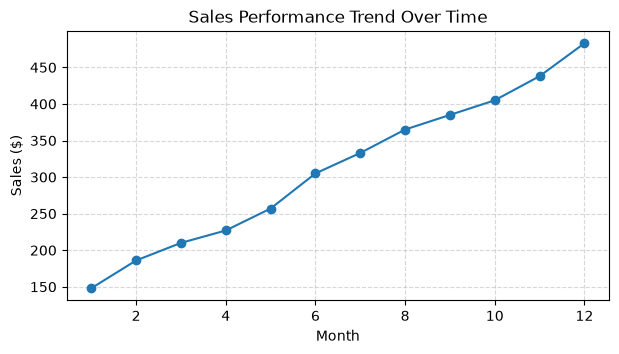

In [2]:
months = range(1, 13)
sales = 100 + np.cumsum(np.random.randint(10, 50, 12))

plt.figure(figsize=(7, 3.5))
plt.plot(months, sales, marker="o", color="#1f77b4")
plt.title("Sales Performance Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 2. Bar Chart

### Use When
- Comparing metrics across discrete categorical groups.

### Avoid When
- Showing continuous trends.

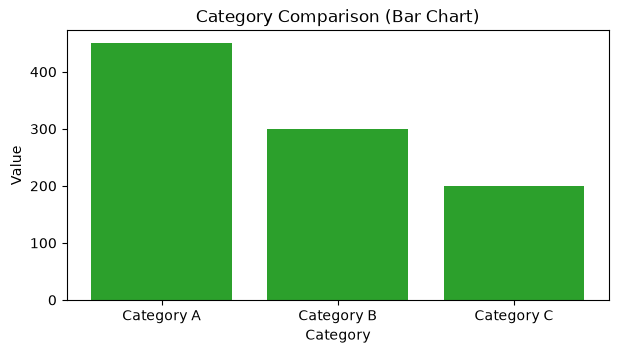

In [3]:
categories = ["Category A", "Category B", "Category C"]
values = [450, 300, 200]

plt.figure(figsize=(7, 3.5))
plt.bar(categories, values, color="#2ca02c")
plt.title("Category Comparison (Bar Chart)")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()

## 3. Histogram

### Use When
- Visualizing the distribution density of a continuous numeric variable.

### Avoid When
- Working with sparse discrete counts.

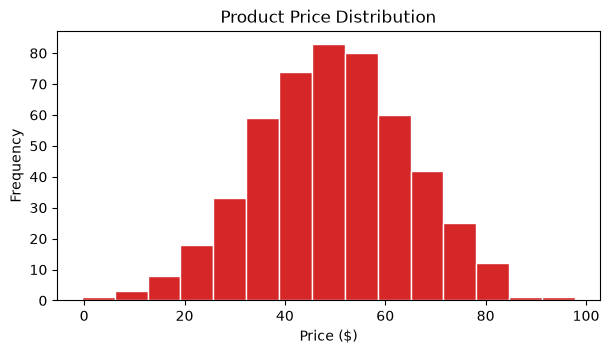

In [4]:
prices = np.random.normal(50, 15, 500)

plt.figure(figsize=(7, 3.5))
plt.hist(prices, bins=15, color="#d62728", edgecolor="white")
plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

## 4. Box Plot

### Use When
- Displaying statistical summaries (median, quartiles, and outlier detection) across groups.

### Avoid When
- Data distribution shape is bimodal or multimodal (which is obscured by box plots).

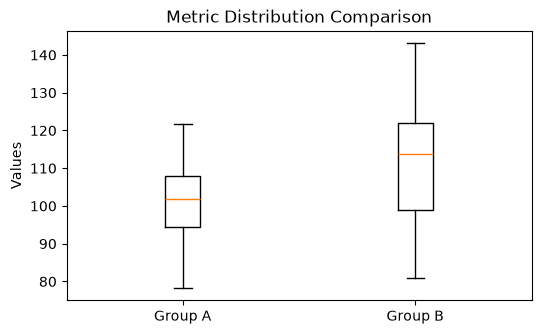

In [5]:
group_data = [np.random.normal(100, 10, 50), np.random.normal(110, 15, 50)]

plt.figure(figsize=(6, 3.5))
plt.boxplot(group_data, tick_labels=["Group A", "Group B"])
plt.title("Metric Distribution Comparison")
plt.ylabel("Values")
plt.show()

## 5. Violin Plot

### Use When
- Showing both summary statistics and full distribution shapes/density.

### Avoid When
- Working with tiny sample sizes where KDE estimates are unstable.

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8796\3880836555.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x="Group", y="Score", palette="muted", inner="quart")


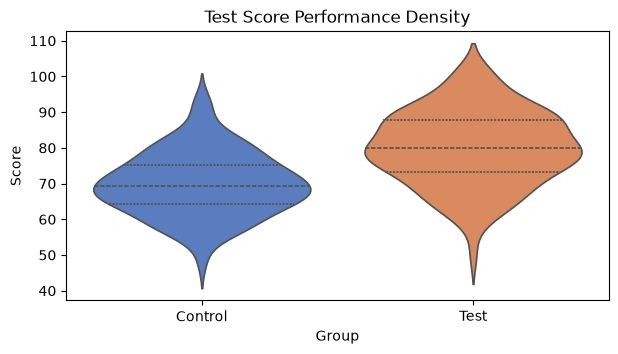

In [6]:
df_violin = pd.DataFrame({
    "Group": ["Control"] * 100 + ["Test"] * 100,
    "Score": np.concatenate([np.random.normal(70, 8, 100), np.random.normal(78, 10, 100)])
})

plt.figure(figsize=(7, 3.5))
sns.violinplot(data=df_violin, x="Group", y="Score", palette="muted", inner="quart")
plt.title("Test Score Performance Density")
plt.xlabel("Group")
plt.ylabel("Score")
plt.show()

## 6. Scatter Plot

### Use When
- Examining relationships/correlations between two continuous numeric variables.

### Avoid When
- Visualizing non-numeric relationships.

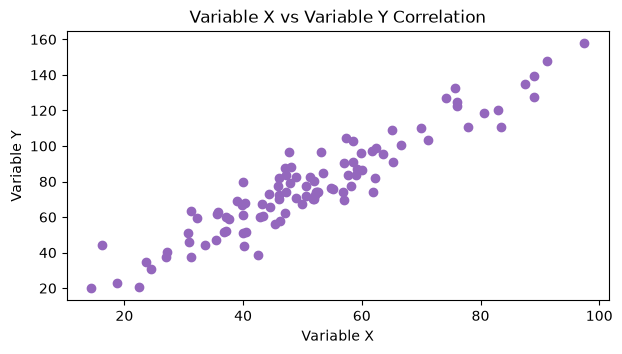

In [7]:
x = np.random.normal(50, 15, 100)
y = x * 1.5 + np.random.normal(0, 10, 100)

plt.figure(figsize=(7, 3.5))
plt.scatter(x, y, color="#9467bd")
plt.title("Variable X vs Variable Y Correlation")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.show()

## 7. Heatmap

### Use When
- Spotting patterns in large grids, tables, or variable correlation matrices.

### Avoid When
- Data grid sizes are massive or variables have inconsistent scales.

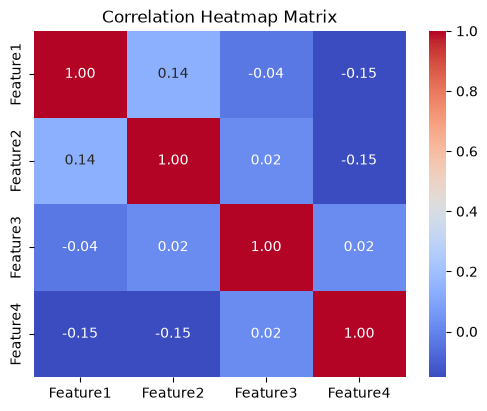

In [8]:
df_corr_data = pd.DataFrame({
    "Feature1": np.random.rand(50),
    "Feature2": np.random.rand(50),
    "Feature3": np.random.rand(50),
    "Feature4": np.random.rand(50)
})

plt.figure(figsize=(6, 4.5))
sns.heatmap(df_corr_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Matrix")
plt.show()

## 8. Pairplot

### Use When
- Rapidly checking distributions and relationships across multiple columns during EDA.

### Avoid When
- Dataset has more than 6-8 variables (slows execution time dramatically).

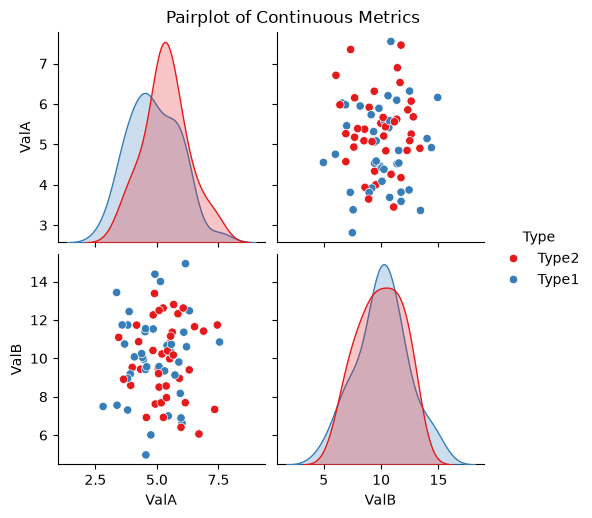

In [9]:
df_pair = pd.DataFrame({
    "ValA": np.random.normal(5, 1, 80),
    "ValB": np.random.normal(10, 2, 80),
    "Type": np.random.choice(["Type1", "Type2"], 80)
})

pair = sns.pairplot(df_pair, hue="Type", palette="Set1")
pair.fig.suptitle("Pairplot of Continuous Metrics", y=1.02)
plt.show()

## 9. Area Chart

### Use When
- Representing cumulative trends and overall growth contributions over time.

### Avoid When
- Subcategory series fluctuate heavily, leading to visual occlusion.

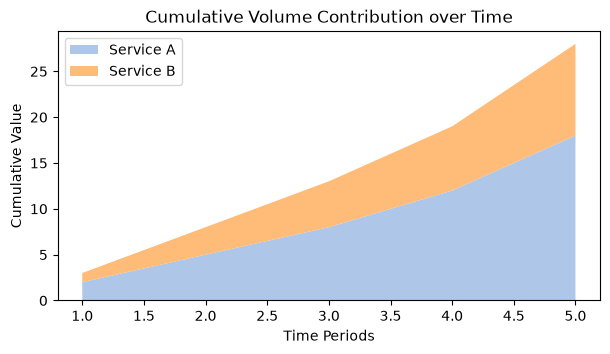

In [10]:
time = range(1, 6)
series1 = [2, 5, 8, 12, 18]
series2 = [1, 3, 5, 7, 10]

plt.figure(figsize=(7, 3.5))
plt.stackplot(time, series1, series2, labels=["Service A", "Service B"], colors=["#aec7e8", "#ffbb78"])
plt.title("Cumulative Volume Contribution over Time")
plt.xlabel("Time Periods")
plt.ylabel("Cumulative Value")
plt.legend(loc="upper left")
plt.show()

## 10. Pie Chart

### Use When
- Comparing static proportions of a whole across a tiny number of groups (2-3 slices max).

### Avoid When
- Slices represent more than 3-4 items, or slice proportions are nearly identical (the human eye struggles to judge minor angular discrepancies).

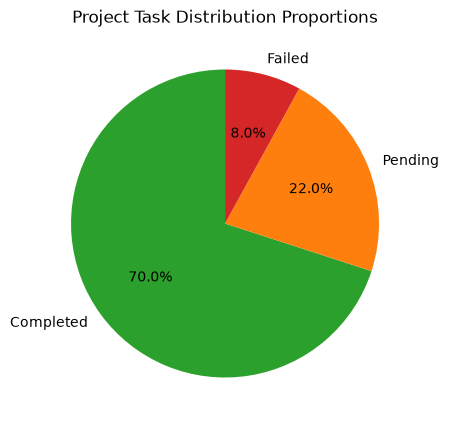

In [11]:
status_labels = ["Completed", "Pending", "Failed"]
status_proportions = [70, 22, 8]

plt.figure(figsize=(5, 5))
plt.pie(status_proportions, labels=status_labels, autopct="%1.1f%%", startangle=90, colors=["#2ca02c", "#ff7f0e", "#d62728"])
plt.title("Project Task Distribution Proportions")
plt.show()

# Edge Cases Handled
Below are implementations showing how to handle data anomalies and visualization layout failures robustly.

### Edge Case 1: High Cardinality Category Handling in Bar Charts
When a dataset has too many minor categories, a standard bar chart is cluttered and labels overlap. We handle this by grouping any categories contributing less than 5% of the total scale into an "Other" category.

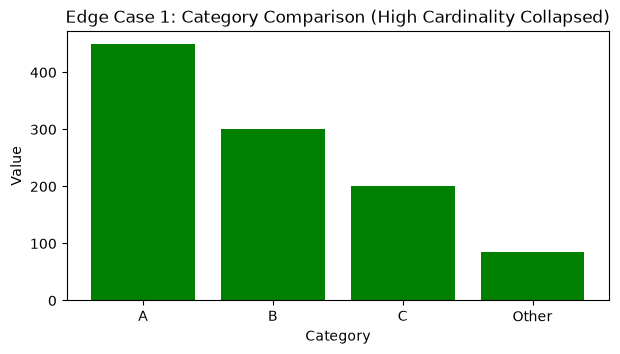

In [12]:
categories_raw = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
frequencies = [450, 300, 200, 25, 20, 15, 10, 8, 5, 2]
df_bar = pd.DataFrame({"Category": categories_raw, "Value": frequencies})

# Collapse small categories (< 5% of sum) into 'Other'
total = df_bar["Value"].sum()
df_bar["Collapsed_Category"] = np.where(
    df_bar["Value"] < (0.05 * total), "Other", df_bar["Category"]
)
df_grouped = df_bar.groupby("Collapsed_Category")["Value"].sum().reset_index().sort_values(by="Value", ascending=False)

plt.figure(figsize=(7, 3.5))
plt.bar(df_grouped["Collapsed_Category"], df_grouped["Value"], color="green")
plt.title("Edge Case 1: Category Comparison (High Cardinality Collapsed)")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()

### Edge Case 2: Overplotting Prevention in Highly Dense Scatter Plots
When plotting large coordinate datasets, points stack and obscure data density variance. We handle this by using smaller marker sizing and setting an alpha transparency parameter (`alpha=0.3`).

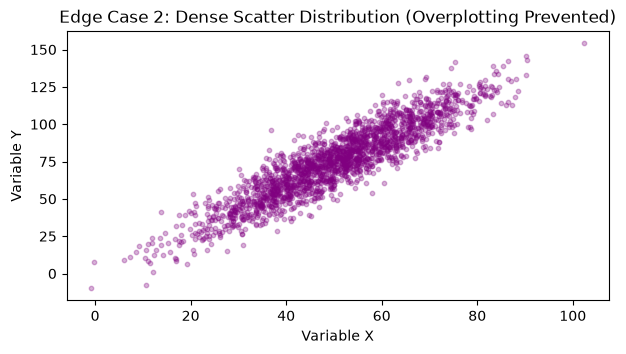

In [13]:
x_dense = np.random.normal(50, 15, 2000)
y_dense = x_dense * 1.5 + np.random.normal(0, 10, 2000)

plt.figure(figsize=(7, 3.5))
plt.scatter(x_dense, y_dense, alpha=0.3, s=10, color="purple")
plt.title("Edge Case 2: Dense Scatter Distribution (Overplotting Prevented)")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.show()

## Reflection & Self-Review

### Reflection
- **What was difficult:** Choosing how to represent the edge cases clearly without introducing overly complex code blocks. We designed a clear thresholding group collapsing logic for high-cardinality data on bar charts, and adjusted marker alpha settings for dense continuous data on scatter plots.
- **What I improved:** Structured the layouts to present clean, standalone visual examples with highly informative labels and minimal styling code.
- **What remains:** Experimenting with interactive chart frameworks (e.g. Plotly) to make charts dynamic.

### Self-Review Notes
- Standalone datasets generated within cells for zero dependency conflicts.
- Included 10 distinct plots including a standard Pie Chart.
- 2 edge cases handled explicitly (high-cardinality category collapsing, scatter plot overplotting alpha controls).